In [1]:
level_depth=0

In [2]:
from IPython.display import display
import os
import numpy as np
import pandas as pd

import plotly.express as px  # per il grafico lineare


In [3]:
#STRATEGY 1

'''
Tables in DB: [('chats',)]
number of unique chats 127141
chats.db - Tabella 'chats'
           type_and_id                   token                  parent  \
0                 None  [keyword] thedemocrats                    None   
40  channel_1889806290         thedemocratskmf  [keyword] thedemocrats   
41  channel_1413288788       thedemocratsindia  [keyword] thedemocrats      

       timestamp  
0   1.722583e+09  
40  1.728093e+09  
41  1.728093e+09  

✅ discovery_edges.csv.gz, 
Il timestamp da l'ultima volta che hanno visitato quel gruppo ma questo significa che non è davvero indicativo di una timeline 

          type_and_id              parent     timestamp
0  channel_1306559115  channel_1840578235  1.722586e+09
1  channel_2036850729  channel_1840578235  1.722586e+09
2  channel_1941222046  channel_1840578235  1.722586e+09

number of non unique first nodes 284
✅ first_nodes.csv.gz
          type_and_id                    token                      parent
0  channel_2036421633               trump2024e         [keyword] Trump2024
1  channel_2178554925  biden_has_left_the_chat             [keyword] Biden
2  channel_2095394414             speech_biden      [keyword] Joseph Biden

number of unique first nodes 247
'''

#paths
path_summary_filtered = f"../results/levels/level_{level_depth}/percentage_of_politics_msgs/summary_pol_sorted_filtered_spam.csv.gz"
path_df_edges = f"../material/discovery_edges.csv.gz"

# load summary with pol_ratio_without_spam for every channel_id
summary_filtered  = pd.read_csv(path_summary_filtered, compression="gzip")
print(f"len summary_filtered = {len(summary_filtered)}")
print(f"summary_filtered:\n {summary_filtered.head()}")

# load discovery_edges
df_edges = pd.read_csv(path_df_edges, compression="gzip")
print(f"df_edges:\n {df_edges.head()}")

#filter for only the istances of channels in summary_filtered
children = df_edges[df_edges['parent'].isin(summary_filtered['channel_id'])].reset_index(drop=True)

#extract the unique istances of type_and_id
df_unique_children = children[['type_and_id']].drop_duplicates().reset_index(drop=True)

#save
print(f"lenght of df_unique_childen {len(df_unique_children)}")





len summary_filtered = 43
summary_filtered:
            channel_id  total_msgs_without_spam  pol_msgs  economy_msgs  \
0  channel_1076871110                      555       211            20   
1  channel_1245638927                      914       403            26   
2  channel_1269157403                      142        36             3   
3  channel_1283801046                       19         7             0   
4  channel_1292024994                       78        41             2   

   crypto_msgs  not_categorized_msgs  spam_msgs  outliers_msgs  \
0           18                    93      28273            213   
1           77                   180        520            228   
2            1                    74          0             28   
3            0                     6          0              6   
4            2                     6          0             27   

   total_msgs_with_spam  pol_ratio_without_spam  economy_ratio_without_spam  \
0                 28828           

len summary_filtered: 43

len parents_df: 43

len edges_df: 1990

len children_df: 23



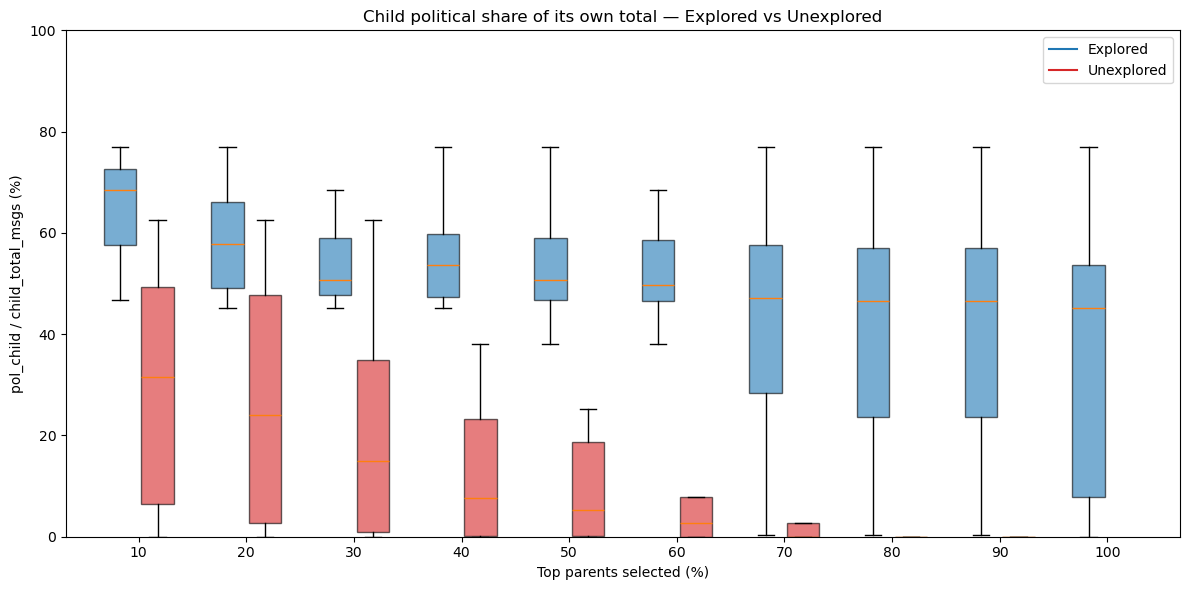

M3 medians (Explored vs Unexplored):
  Top_%  Explored_med%  Unexplored_med%
    10      68.490879        31.589100
    20      57.869321        24.109589
    30      50.654387        15.026282
    40      53.744460         7.692308
    50      50.654387         5.232292
    60      49.717437         2.772277
    70      47.156863         0.000000
    80      46.524823         0.000000
    90      46.524823         0.000000
   100      45.212766              NaN

Counts per fraction (Explored vs Unexplored):
  top_parents_pct  explored_count  unexplored_count  total_children
              10             312              1467            1779
              20             354              1425            1779
              30             371              1408            1779
              40             487              1292            1779
              50             706              1073            1779
              60            1267               512            1779
              70

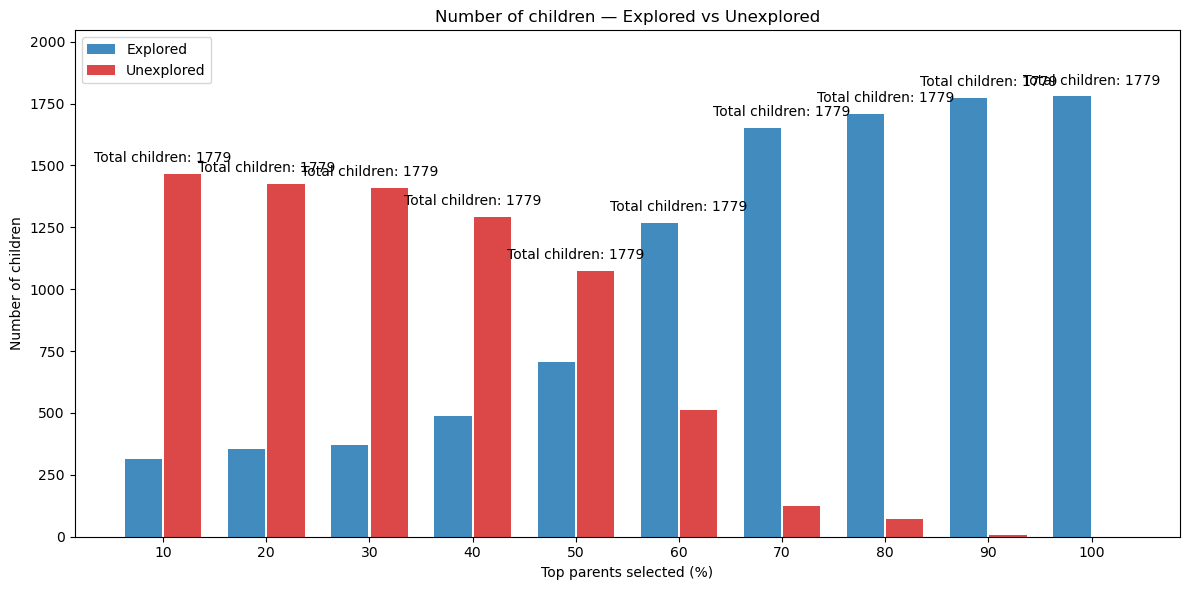

In [4]:
# ============================================
# Build ONLY M3 on YOUR data + show boxplot (Explored vs Unexplored)
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 0) Inputs already loaded by you
# -----------------------------
# Expected to exist:
# - summary_filtered  (from ../results/.../summary_pol_sorted_filtered_spam.csv.gz)
# - df_edges          (from ../material/discovery_edges.csv.gz)
# And you already computed (or equivalent joins below will reproduce):
# - children          = df_edges[df_edges['parent'].isin(summary_filtered['channel_id'])].reset_index(drop=True)
# - df_unique_children= children[['type_and_id']].drop_duplicates().reset_index(drop=True)

# -----------------------------
# 1) Build parents_df (ranking by parent_political_share)
# -----------------------------
print(f"len summary_filtered: {len(summary_filtered)}\n")
summary = summary_filtered.copy()

parents_df = (summary[['channel_id', 'pol_ratio_without_spam']]
              .rename(columns={
                  'channel_id': 'parent_id',
                  'pol_ratio_without_spam': 'parent_political_share'  # percentage 0..100 in your CSV
              })
              .dropna(subset=['parent_id', 'parent_political_share'])
              .copy())
parents_df['parent_political_share'] = parents_df['parent_political_share'].astype(float)

print(f"len parents_df: {len(parents_df)}\n")

# -----------------------------
# 2) Build parent_edges_df (parent_id, child_id) keeping only candidate parents
# -----------------------------
parent_edges_df = (df_edges[df_edges['parent'].isin(parents_df['parent_id'])]
            [['parent', 'type_and_id']]
            .rename(columns={'parent': 'parent_id', 'type_and_id': 'child_id'})
            .dropna(subset=['parent_id', 'child_id'])
            .drop_duplicates()
            .reset_index(drop=True))

print(f"len parent_edges_df: {len(parent_edges_df)}\n")

# -----------------------------
# 3) Build children_df (child_id, political_msgs, total_msgs)
#     Join child_ids from edges with stats in summary
# -----------------------------
children_stats = (summary
                  .rename(columns={'channel_id': 'child_id',
                                   'pol_msgs': 'political_msgs',
                                   'total_msgs_without_spam': 'total_msgs'})
                  [['child_id', 'political_msgs', 'total_msgs']])

children_df = (pd.merge(
                    parent_edges_df[['child_id']].drop_duplicates(),
                    children_stats,
                    on='child_id',
                    how='left')
               .dropna(subset=['political_msgs', 'total_msgs'])
               .copy())

print(f"len children_df: {len(children_df)}\n")

children_df['political_msgs'] = children_df['political_msgs'].astype(float)
children_df['total_msgs']     = children_df['total_msgs'].astype(float)
children_df = children_df[children_df['total_msgs'] > 0].reset_index(drop=True)

# -----------------------------
# 4) Helpers
# -----------------------------
def order_parents(parents_df: pd.DataFrame) -> np.ndarray:
    """Sort parents by political share (desc) and return their IDs."""
    ordered = (parents_df
               .dropna(subset=['parent_political_share'])
               .sort_values('parent_political_share', ascending=False)['parent_id']
               .to_numpy())
    if len(ordered) == 0:
        raise ValueError("No parents available after sorting.")
    return ordered

def compute_m3_both_groups(parents_df, parent_edges_df, children_df,
                           total_col='total_msgs',
                           top_parent_percents=list(range(10, 101, 10))) -> pd.DataFrame:
    """
    Ritorna un DF con colonne: [metric, top_parents_pct, child_id, value_pct, Group]
    Group ∈ {'Explored','Unexplored'}
    """
    child_lookup = (children_df[['child_id','political_msgs', total_col]]
                    .drop_duplicates().set_index('child_id'))
    ordered = order_parents(parents_df)
    n_parents = len(ordered)
    rows = []

    # universo figli nel sottografo dei candidati
    all_children = parent_edges_df['child_id'].dropna().unique()

    for perc in top_parent_percents:
        k = max(1, int(np.ceil(n_parents * (perc/100.0))))
        topk = set(ordered[:k])

        sel = parent_edges_df['parent_id'].isin(topk)
        explored_children = parent_edges_df.loc[sel, 'child_id'].dropna().unique()
        unexplored_children = np.setdiff1d(all_children, explored_children, assume_unique=False)

        # Explored
        if len(explored_children) > 0:
            sub_e = child_lookup.reindex(explored_children)[['political_msgs', total_col]].dropna()
            sub_e = sub_e[sub_e[total_col] > 0]
            vals_e = (sub_e['political_msgs'] / sub_e[total_col]) * 100.0
            for cid, v in zip(sub_e.index, vals_e.to_numpy()):
                rows.append({'metric': f'M3_over_{total_col}',
                             'top_parents_pct': perc,
                             'child_id': cid,
                             'value_pct': float(v),
                             'Group': 'Explored'})
        # Unexplored
        if len(unexplored_children) > 0:
            sub_u = child_lookup.reindex(unexplored_children)[['political_msgs', total_col]].dropna()
            sub_u = sub_u[sub_u[total_col] > 0]
            vals_u = (sub_u['political_msgs'] / sub_u[total_col]) * 100.0
            for cid, v in zip(sub_u.index, vals_u.to_numpy()):
                rows.append({'metric': f'M3_over_{total_col}',
                             'top_parents_pct': perc,
                             'child_id': cid,
                             'value_pct': float(v),
                             'Group': 'Unexplored'})
    return pd.DataFrame(rows)

def make_grouped_boxplot(df: pd.DataFrame, title: str, y_label: str):
    """
    Crea boxplot affiancati per ciascun valore di top_parents_pct.
    df deve avere colonne: top_parents_pct, value_pct, Group in {'Explored','Unexplored'}.
    """
    if len(df) == 0:
        print(f"[WARN] Empty dataframe for plot: {title}")
        return

    fracs = sorted(df['top_parents_pct'].unique())
    groups = ['Explored', 'Unexplored']

    # prepara i dati: lista per gruppo (ognuna è lista delle distribuzioni sulle frazioni)
    data_by_group = {g: [] for g in groups}
    for f in fracs:
        for g in groups:
            vals = df.loc[(df['top_parents_pct'] == f) & (df['Group'] == g), 'value_pct'].to_numpy()
            data_by_group[g].append(vals)

    # posizioni affiancate
    x = np.arange(len(fracs))
    width = 0.35
    pos_expl = x - width/2
    pos_unex = x + width/2

    fig, ax = plt.subplots(figsize=(12, 6))

    # boxplot per gruppo con posizioni custom
    bp1 = ax.boxplot(data_by_group['Explored'], positions=pos_expl, widths=0.3, patch_artist=True, showfliers=False)
    bp2 = ax.boxplot(data_by_group['Unexplored'], positions=pos_unex, widths=0.3, patch_artist=True, showfliers=False)

    # colori
    for patch in bp1['boxes']:
        patch.set_facecolor('#1f77b4')  # blu
        patch.set_alpha(0.6)
    for patch in bp2['boxes']:
        patch.set_facecolor('#d62728')  # rosso
        patch.set_alpha(0.6)

    ax.set_xticks(x)
    ax.set_xticklabels([str(int(f)) for f in fracs])
    ax.set_xlabel("Top parents selected (%)")
    ax.set_ylabel(y_label)
    ax.set_title(title)

    # legenda artigianale
    ax.plot([], [], color='#1f77b4', label='Explored')
    ax.plot([], [], color='#d62728', label='Unexplored')
    ax.legend()
    ax.set_ylim(0, 100)
    fig.tight_layout()
    plt.show()

def quick_medians_by_group(df):
    return (df.groupby(['top_parents_pct','Group'])['value_pct']
              .median().reset_index()
              .pivot(index='top_parents_pct', columns='Group', values='value_pct')
              .rename_axis(None, axis=1)
              .reset_index()
              .rename(columns={'top_parents_pct':'Top_%', 'Explored':'Explored_med%', 'Unexplored':'Unexplored_med%'}))

# -----------------------------
# 5) Compute only M3 metric (Explored + Unexplored)
# -----------------------------
fractions = list(range(10, 101, 10))

m3_both = compute_m3_both_groups(
    parents_df, parent_edges_df, children_df,
    total_col='total_msgs',
    top_parent_percents=fractions
)

# -----------------------------
# 6) Show the grouped boxplot (ONLY M3)
# -----------------------------
make_grouped_boxplot(
    m3_both,
    "Child political share of its own total — Explored vs Unexplored",
    "pol_child / child_total_msgs (%)"
)

# -----------------------------
# 7) Medians (both groups)
# -----------------------------
med = quick_medians_by_group(m3_both)
print("M3 medians (Explored vs Unexplored):\n", med.to_string(index=False))

# -----------------------------
# NOTE
# -----------------------------
# "Explored" = figli collegati a genitori nei top-k (per ciascuna frazione).
# "Unexplored" = gli altri figli (nello stesso sottografo dei candidati) esclusi da quei top-k.
# Così vedi come cambia la distribuzione M3 in funzione dell'espansione dei genitori selezionati.

# =====================================================================
# NEW: Counts per fraction + bar chart (Explored vs Unexplored, in EN)
# =====================================================================

def compute_child_counts(parents_df, parent_edges_df, top_parent_percents=list(range(10, 101, 10))) -> pd.DataFrame:
    """
    Conta, per ogni percentuale di top parents, quanti child sono:
      - Explored: collegati ad almeno un parent nei top-k
      - Unexplored: tutti gli altri (nel sottografo dei candidati)
    Usa SOLO parent_edges_df (nessun filtro sui messaggi), così che:
      - a 100%: explored_count == total_children e unexplored_count == 0

    Ritorna colonne: [top_parents_pct, explored_count, unexplored_count, total_children]
    """
    ordered = order_parents(parents_df)
    n_parents = len(ordered)
    all_children = parent_edges_df['child_id'].dropna().unique()
    total_children = int(len(all_children))

    rows = []
    for perc in sorted(top_parent_percents):
        k = max(1, int(np.ceil(n_parents * (perc/100.0))))
        topk = set(ordered[:k])

        sel = parent_edges_df['parent_id'].isin(topk)
        explored_children = np.unique(parent_edges_df.loc[sel, 'child_id'].dropna().to_numpy())
        unexplored_children = np.setdiff1d(all_children, explored_children, assume_unique=False)

        rows.append({
            'top_parents_pct': int(perc),
            'explored_count' : int(len(explored_children)),
            'unexplored_count': int(len(unexplored_children)),
            'total_children'  : total_children
        })

    counts_df = pd.DataFrame(rows)
    # Sanity check (Esempio numerico: se total_children=1200 allora a 100% -> explored=1200, unexplored=0)
    last = counts_df[counts_df['top_parents_pct'] == max(top_parent_percents)].iloc[0]
    if not (last['explored_count'] == last['total_children'] and last['unexplored_count'] == 0):
        print("[WARN] 100% fraction does not satisfy explored == total and unexplored == 0. Check inputs.")
    return counts_df

def make_counts_plot(counts_df: pd.DataFrame):
    """
    Grafico richiesto: per ogni x (top_parents_pct) sulla y i conteggi di children
    Explored vs Unexplored (barre affiancate). Annotazione sopra ad ogni x con:
      'Total children: N'
    Etichette in inglese. NON modifica il grafico originale (nuova figura separata).
    """
    if counts_df.empty:
        print("[WARN] Empty counts_df; nothing to plot.")
        return

    fracs = counts_df['top_parents_pct'].astype(int).tolist()
    explored = counts_df['explored_count'].to_numpy()
    unexplored = counts_df['unexplored_count'].to_numpy()
    totals = counts_df['total_children'].to_numpy()

    x = np.arange(len(fracs))
    width = 0.38
    pos_expl = x - width/2
    pos_unex = x + width/2

    fig, ax = plt.subplots(figsize=(12, 6))
    # Stesse palette del boxplot per coerenza visiva
    b1 = ax.bar(pos_expl, explored, width=0.36, color='#1f77b4', alpha=0.85, label='Explored')
    b2 = ax.bar(pos_unex, unexplored, width=0.36, color='#d62728', alpha=0.85, label='Unexplored')

    ax.set_xticks(x)
    ax.set_xticklabels([str(f) for f in fracs])
    ax.set_xlabel("Top parents selected (%)")
    ax.set_ylabel("Number of children")
    ax.set_title("Number of children — Explored vs Unexplored")

    ax.legend()

    # Annotazioni del totale sopra ogni coppia di barre
    # (posiziono l’etichetta al centro fra le due barre, appena sopra l’altezza massima)
    for i, (xe, xu, e, u, tot) in enumerate(zip(pos_expl, pos_unex, explored, unexplored, totals)):
        x_mid = (xe + xu) / 2.0
        y_top = max(e, u)
        ax.text(x_mid, y_top + max(1, 0.02 * max(totals)), f"Total children: {int(tot)}",
                ha='center', va='bottom', fontsize=10, rotation=0)

    ax.set_ylim(0, max(totals) * 1.15 if len(totals) else None)
    fig.tight_layout()
    plt.show()

# ---- Run the new counts + plot (keeps original plot untouched) ----
counts_df = compute_child_counts(parents_df, parent_edges_df, top_parent_percents=fractions)
print("\nCounts per fraction (Explored vs Unexplored):\n", counts_df.to_string(index=False))
make_counts_plot(counts_df)
